# Notebook 03 — Modeling
**DNSC 6330 Capstone | HMDA LAR 2024**

Goals:
- Establish a transparent logistic regression baseline
- Compare it against higher-capacity tree models under a reproducible compute budget
- Optimize the approval decision threshold using the precision-recall curve
- Save the best model and deployment metadata for downstream fairness, explainability, and robustness notebooks

> **Optimization objective:** Predict `label=1` (approved) and maximize approval-class F1 at a transparent threshold. Under this label scheme, wrongful denials are **false negatives**, so recall for the approval class is the applicant-harm metric we monitor most closely.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

import os
import json

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR  = os.path.join(BASE_DIR, 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, log_loss,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

RANDOM_STATE = 42
print('Imports OK')
print(f'BASE_DIR: {BASE_DIR}')

Imports OK
BASE_DIR: /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code


In [2]:
from sklearn.utils import resample

MODEL_SAMPLE_SIZE = 500_000
TUNE_SAMPLE_SIZE = 100_000
RF_FIT_SAMPLE_SIZE = 200_000


def stratified_subsample(X, y, n_samples, random_state=42):
    if len(X) <= n_samples:
        return X.copy(), y.copy()
    idx = resample(
        np.arange(len(X)),
        replace=False,
        n_samples=n_samples,
        stratify=y,
        random_state=random_state,
    )
    idx = np.sort(idx)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)

print('Modeling notebook uses fixed compute budgets for reproducibility:')
print(f'  MODEL_SAMPLE_SIZE = {MODEL_SAMPLE_SIZE:,}')
print(f'  TUNE_SAMPLE_SIZE  = {TUNE_SAMPLE_SIZE:,}')
print(f'  RF_FIT_SAMPLE_SIZE = {RF_FIT_SAMPLE_SIZE:,}')

Modeling notebook uses fixed compute budgets for reproducibility:
  MODEL_SAMPLE_SIZE = 500,000
  TUNE_SAMPLE_SIZE  = 100,000
  RF_FIT_SAMPLE_SIZE = 200,000


## 1. Load Data

In [3]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train_imputed.parquet'))
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test_imputed.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

DROP_FEATURES = ['loan_amount', 'loan_term', 'loan_to_value_ratio']
to_drop = [c for c in DROP_FEATURES if c in X_train.columns]
if to_drop:
    X_train = X_train.drop(columns=to_drop)
    X_test  = X_test.drop(columns=to_drop)
    print(f'Dropped features: {to_drop}')

assert list(X_train.columns) == list(X_test.columns), 'X_train and X_test have different columns — re-run NB02 before continuing.'
print(f'Feature alignment OK — {X_train.shape[1]} columns')
print('Features:', X_train.columns.tolist())
print()
print(f'X_train: {X_train.shape}  |  approval rate: {y_train.mean():.2%}')
print(f'X_test:  {X_test.shape}   |  approval rate: {y_test.mean():.2%}')

X_model_train, y_model_train = stratified_subsample(X_train, y_train, MODEL_SAMPLE_SIZE, RANDOM_STATE)
X_tune_train, y_tune_train = stratified_subsample(X_train, y_train, TUNE_SAMPLE_SIZE, RANDOM_STATE)
X_rf_train, y_rf_train = stratified_subsample(X_train, y_train, RF_FIT_SAMPLE_SIZE, RANDOM_STATE)

n_pos = y_model_train.sum()
n_neg = len(y_model_train) - n_pos
class_weight_ratio = n_neg / n_pos

print() 
print(f'Model fit sample: {X_model_train.shape}')
print(f'Tuning sample:    {X_tune_train.shape}')
print(f'RF fit sample:    {X_rf_train.shape}')
print(f'Class weight ratio (denied/approved): {class_weight_ratio:.3f}')

Dropped features: ['loan_amount', 'loan_term']
Feature alignment OK — 21 columns
Features: ['income', 'debt_to_income_ratio', 'property_value', 'has_credit_score', 'co_applicant_has_credit_score', 'loan_type_2', 'loan_type_3', 'loan_type_4', 'loan_purpose_2', 'loan_purpose_4', 'loan_purpose_5', 'loan_purpose_31', 'loan_purpose_32', 'occupancy_type_2', 'occupancy_type_3', 'lien_status_2', 'conforming_loan_limit_NC', 'conforming_loan_limit_U', 'preapproval_2', 'submission_of_application_2', 'submission_of_application_1111']

X_train: (6929418, 21)  |  approval rate: 75.72%
X_test:  (1732355, 21)   |  approval rate: 75.72%



Model fit sample: (500000, 21)
Tuning sample:    (100000, 21)
RF fit sample:    (200000, 21)
Class weight ratio (denied/approved): 0.321


In [4]:
# ── Downstream notebook alignment note ───────────────────────────────────────
# NB04, NB05, and NB06 must load X_test from the SAME parquet files used here.
# If you see a feature mismatch error in a downstream notebook, it means either:
#   (a) best_model.pkl is stale (from a previous run with fewer features) — fix: re-run this notebook
#   (b) the downstream notebook is loading a different parquet than NB02 produced
#
# The saved model_meta.json now includes 'feature_columns' — downstream notebooks
# can use this to verify alignment:
#
#   with open('model_meta.json') as f: meta = json.load(f)
#   expected = meta['feature_columns']
#   assert X_test.columns.tolist() == expected, f"Feature mismatch: got {X_test.columns.tolist()}"

print('Downstream notebooks (NB04, NB05, NB06) should load:')
print('  X_test_imputed.parquet  — produced by NB02, same columns as X_train_imputed.parquet')
print('  best_model.pkl          — produced by this notebook, trained on those exact columns')
print('  model_meta.json         — includes feature_columns list for alignment verification')
print()
print('If any downstream notebook raises a feature name mismatch error,')
print('re-run THIS notebook (NB03) to regenerate best_model.pkl on the current feature set.')


Downstream notebooks (NB04, NB05, NB06) should load:
  X_test_imputed.parquet  — produced by NB02, same columns as X_train_imputed.parquet
  best_model.pkl          — produced by this notebook, trained on those exact columns
  model_meta.json         — includes feature_columns list for alignment verification

If any downstream notebook raises a feature name mismatch error,
re-run THIS notebook (NB03) to regenerate best_model.pkl on the current feature set.


## 2. Evaluation Helper

A single function used consistently across all models to avoid cherry-picking metrics.

In [5]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, threshold=0.5, name='Model'):
    """Compute a consistent train/test scorecard for each candidate model."""
    tr_prob = model.predict_proba(X_tr)[:, 1]
    te_prob = model.predict_proba(X_te)[:, 1]
    tr_pred = (tr_prob >= threshold).astype(int)
    te_pred = (te_prob >= threshold).astype(int)

    def metrics(y, prob, pred):
        return {
            'AUC': roc_auc_score(y, prob),
            'Accuracy': accuracy_score(y, pred),
            'F1': f1_score(y, pred),
            'F1_denial': f1_score(y, pred, pos_label=0),
            'Log Loss': log_loss(y, prob),
            'Brier': brier_score_loss(y, prob),
        }

    tr_m = metrics(y_tr, tr_prob, tr_pred)
    te_m = metrics(y_te, te_prob, te_pred)

    print(f'\n══ {name} (threshold={threshold:.3f}) ══')
    print(f'{"Metric":<12} {"Train":>10} {"Test":>10} {"Gap":>10}')
    print('-' * 45)
    for k in tr_m:
        gap = te_m[k] - tr_m[k]
        print(f'{k:<12} {tr_m[k]:>10.4f} {te_m[k]:>10.4f} {gap:>+10.4f}')

    return {
        'name': name,
        'threshold': threshold,
        'train': tr_m,
        'test': te_m,
        'test_prob': te_prob,
        'test_pred': te_pred,
    }

## 3. Baseline — Logistic Regression

A transparent baseline matters in a regulated lending setting. Even if a tree model wins on performance, the logistic model is our white-box benchmark for auditability and sanity checking.

In [6]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
    )),
])

lr_pipe.fit(X_model_train, y_model_train)
lr_results = evaluate_model(
    lr_pipe,
    X_model_train,
    y_model_train,
    X_test,
    y_test,
    name='Logistic Regression',
)


══ Logistic Regression (threshold=0.500) ══
Metric            Train       Test        Gap
---------------------------------------------
AUC              0.7455     0.7428    -0.0027
Accuracy         0.7072     0.7050    -0.0022
F1               0.7881     0.7863    -0.0018
F1_denial        0.5265     0.5239    -0.0027
Log Loss         0.5881     0.5897    +0.0016
Brier            0.2023     0.2031    +0.0008


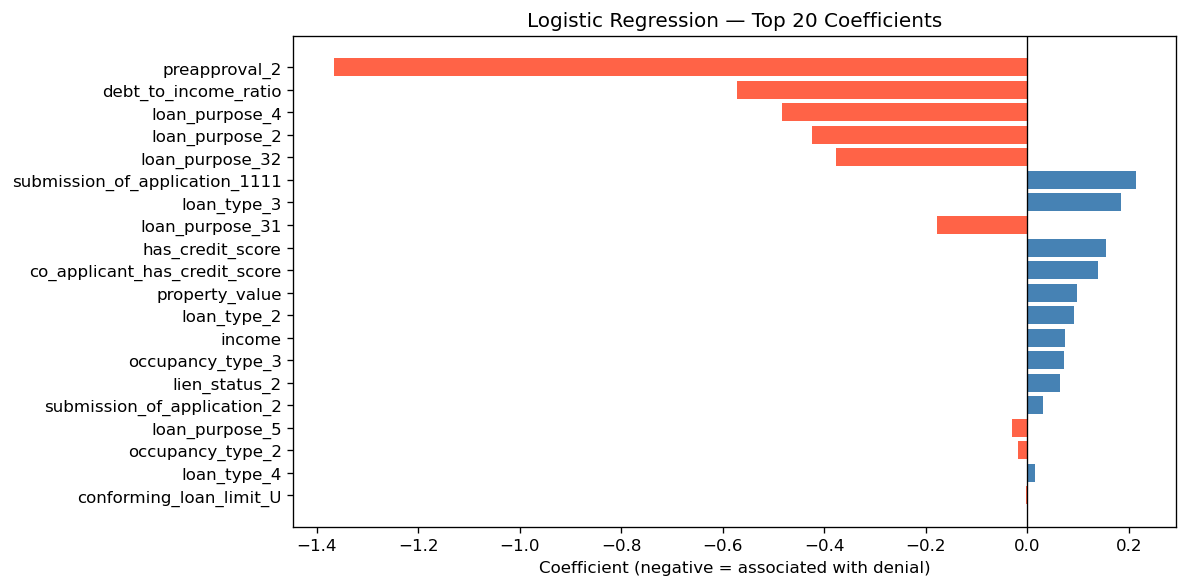

In [7]:
# Top logistic regression coefficients
coef = pd.Series(
    lr_pipe.named_steps['clf'].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
top_coef = coef.head(20)
colors = ['tomato' if v < 0 else 'steelblue' for v in top_coef.values]
ax.barh(top_coef.index, top_coef.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (negative = associated with denial)')
ax.set_title('Logistic Regression — Top 20 Coefficients')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '03_lr_coefficients.png'))
plt.show()

## 4. Candidate Model — Random Forest

The random forest is evaluated under a smaller training budget because it is materially slower on this dataset. It remains useful as a nonlinear benchmark, but not as the final production candidate unless it clearly beats gradient boosting.

In [8]:
rf_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10],
    'min_samples_leaf': [10, 20],
    'max_features': ['sqrt'],
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=1,
)

rf_search = RandomizedSearchCV(
    rf_base,
    rf_param_dist,
    n_iter=4,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
)

rf_search.fit(X_tune_train, y_tune_train)
print(f'Best RF params: {rf_search.best_params_}')
print(f'Best CV F1 (approval class): {rf_search.best_score_:.4f}')

rf_model = RandomForestClassifier(
    **rf_search.best_params_,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=1,
)
rf_model.fit(X_rf_train, y_rf_train)
rf_results = evaluate_model(
    rf_model,
    X_rf_train,
    y_rf_train,
    X_test,
    y_test,
    name='Random Forest',
)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


Best RF params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10}
Best CV F1 (approval class): 0.8468



══ Random Forest (threshold=0.500) ══
Metric            Train       Test        Gap
---------------------------------------------
AUC              0.8365     0.8321    -0.0043
Accuracy         0.7814     0.7778    -0.0036
F1               0.8484     0.8459    -0.0025
F1_denial        0.6082     0.6021    -0.0061
Log Loss         0.4969     0.5003    +0.0034
Brier            0.1609     0.1624    +0.0014


## 5. Primary Model — Gradient Boosting

Gradient boosting is the primary candidate because it usually captures nonlinear lending patterns better than logistic regression while remaining substantially lighter and easier to audit than more exotic ensembles.

In [9]:
gb_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.10, 0.20],
    'subsample': [0.7, 0.9],
}

gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_search = RandomizedSearchCV(
    gb_base,
    gb_param_dist,
    n_iter=6,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    random_state=RANDOM_STATE,
    verbose=1,
)

tune_weights = np.where(y_tune_train == 0, class_weight_ratio, 1.0)
gb_search.fit(X_tune_train, y_tune_train, sample_weight=tune_weights)
print(f'Best GBM params: {gb_search.best_params_}')
print(f'Best CV F1 (approval class): {gb_search.best_score_:.4f}')

gb_model = GradientBoostingClassifier(
    **gb_search.best_params_,
    random_state=RANDOM_STATE,
)
fit_weights = np.where(y_model_train == 0, class_weight_ratio, 1.0)
gb_model.fit(X_model_train, y_model_train, sample_weight=fit_weights)
gb_results = evaluate_model(
    gb_model,
    X_model_train,
    y_model_train,
    X_test,
    y_test,
    name='Gradient Boosting',
)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


Best GBM params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2}
Best CV F1 (approval class): 0.8970



══ Gradient Boosting (threshold=0.500) ══
Metric            Train       Test        Gap
---------------------------------------------
AUC              0.8440     0.8424    -0.0015
Accuracy         0.8283     0.8276    -0.0007
F1               0.8974     0.8970    -0.0004
F1_denial        0.4744     0.4717    -0.0027
Log Loss         0.4434     0.4459    +0.0025
Brier            0.1343     0.1350    +0.0008


## 6. Model Comparison Table

In [10]:
all_results = [lr_results, rf_results, gb_results]

rows = []
for r in all_results:
    rows.append({
        'Model': r['name'],
        'Threshold Used': round(r['threshold'], 4),
        'Train AUC': round(r['train']['AUC'], 4),
        'Test AUC': round(r['test']['AUC'], 4),
        'Test F1': round(r['test']['F1'], 4),
        'Test F1 Denial': round(r['test']['F1_denial'], 4),
        'Test Accuracy': round(r['test']['Accuracy'], 4),
        'Test Brier': round(r['test']['Brier'], 4),
        'G_gap AUC': round(r['test']['AUC'] - r['train']['AUC'], 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model').sort_values(['Test F1', 'Test AUC'], ascending=False)
print('── Model Comparison Table (default threshold = 0.5) ──')
print(comparison_df.to_string())
comparison_df.to_csv(os.path.join(TABLES_DIR, '03_model_comparison_default_threshold.csv'))
print('Saved → tables/03_model_comparison_default_threshold.csv')

── Model Comparison Table (default threshold = 0.5) ──
                     Threshold Used  Train AUC  Test AUC  Test F1  Test F1 Denial  Test Accuracy  Test Brier  G_gap AUC
Model                                                                                                                  
Gradient Boosting               0.5     0.8440    0.8424   0.8970          0.4717         0.8276      0.1350    -0.0015
Random Forest                   0.5     0.8365    0.8321   0.8459          0.6021         0.7778      0.1624    -0.0043
Logistic Regression             0.5     0.7455    0.7428   0.7863          0.5239         0.7050      0.2031    -0.0027
Saved → tables/03_model_comparison_default_threshold.csv


## 7. Threshold Selection

The default threshold of `0.5` is arbitrary. We tune the operating point on the **approval** precision-recall curve because the model predicts approvals (`label=1`). Under this label convention, lower recall means more wrongful denials.

Tuning threshold for: Gradient Boosting


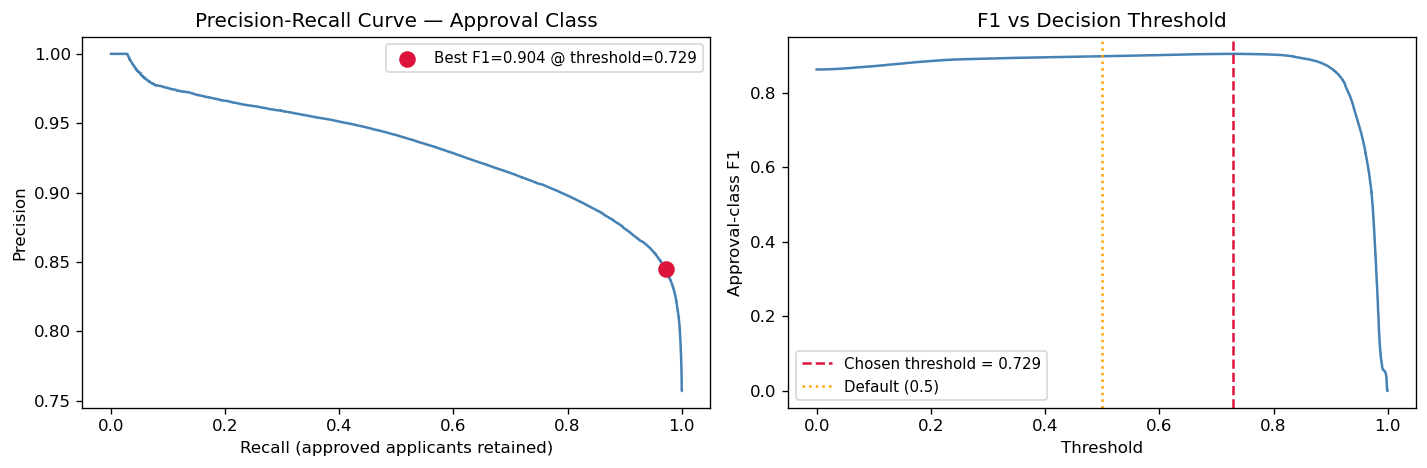

Chosen threshold: 0.7289
F1 at chosen threshold: 0.9037


In [11]:
best_result = max(all_results, key=lambda r: (r['test']['F1'], r['test']['AUC']))
if best_result['name'] == 'Random Forest':
    best_model = rf_model
elif best_result['name'] == 'Gradient Boosting':
    best_model = gb_model
else:
    best_model = lr_pipe

best_name = best_result['name']
best_probs = best_result['test_prob']
print(f'Tuning threshold for: {best_name}')

precision, recall, thresholds = precision_recall_curve(y_test, best_probs)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_thresh_idx = np.argmax(f1_scores[:-1])
best_threshold = float(thresholds[best_thresh_idx])
best_f1 = float(f1_scores[best_thresh_idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(recall, precision, color='steelblue', linewidth=1.5)
axes[0].scatter(
    recall[best_thresh_idx],
    precision[best_thresh_idx],
    color='crimson',
    zorder=5,
    s=80,
    label=f'Best F1={best_f1:.3f} @ threshold={best_threshold:.3f}',
)
axes[0].set_xlabel('Recall (approved applicants retained)')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve — Approval Class')
axes[0].legend(fontsize=9)

axes[1].plot(thresholds, f1_scores[:-1], color='steelblue', linewidth=1.5)
axes[1].axvline(best_threshold, color='crimson', linestyle='--', label=f'Chosen threshold = {best_threshold:.3f}')
axes[1].axvline(0.5, color='orange', linestyle=':', label='Default (0.5)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Approval-class F1')
axes[1].set_title('F1 vs Decision Threshold')
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '03_threshold_selection.png'))
plt.show()

print(f'Chosen threshold: {best_threshold:.4f}')
print(f'F1 at chosen threshold: {best_f1:.4f}')

In [12]:
final_results = evaluate_model(
    best_model,
    X_model_train if best_name != 'Random Forest' else X_rf_train,
    y_model_train if best_name != 'Random Forest' else y_rf_train,
    X_test,
    y_test,
    threshold=best_threshold,
    name=f'{best_name} (tuned threshold={best_threshold:.3f})',
)


══ Gradient Boosting (tuned threshold=0.729) (threshold=0.729) ══
Metric            Train       Test        Gap
---------------------------------------------
AUC              0.8440     0.8424    -0.0015
Accuracy         0.8448     0.8433    -0.0015
F1               0.9046     0.9037    -0.0009
F1_denial        0.5833     0.5785    -0.0048
Log Loss         0.4434     0.4459    +0.0025
Brier            0.1343     0.1350    +0.0008


## 8. Confusion Matrix

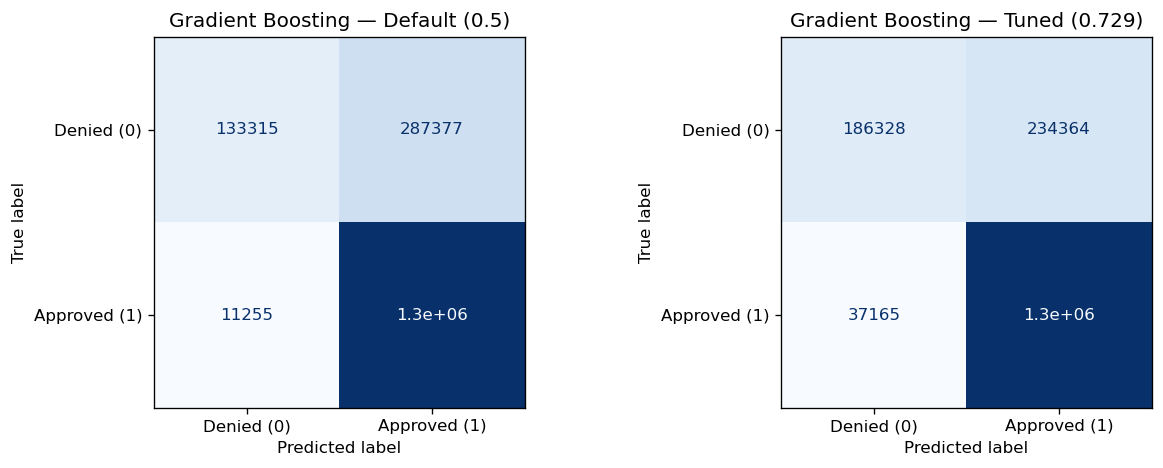

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (result, thresh, title) in zip(axes, [
    (best_result,   0.5,            f'{best_name} — Default (0.5)'),
    (final_results, best_threshold, f'{best_name} — Tuned ({best_threshold:.3f})'),
]):
    preds = (result['test_prob'] >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Denied (0)', 'Approved (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '03_confusion_matrices.png'))  # FIXED: fig.savefig
plt.show()

## 9. ROC Curve

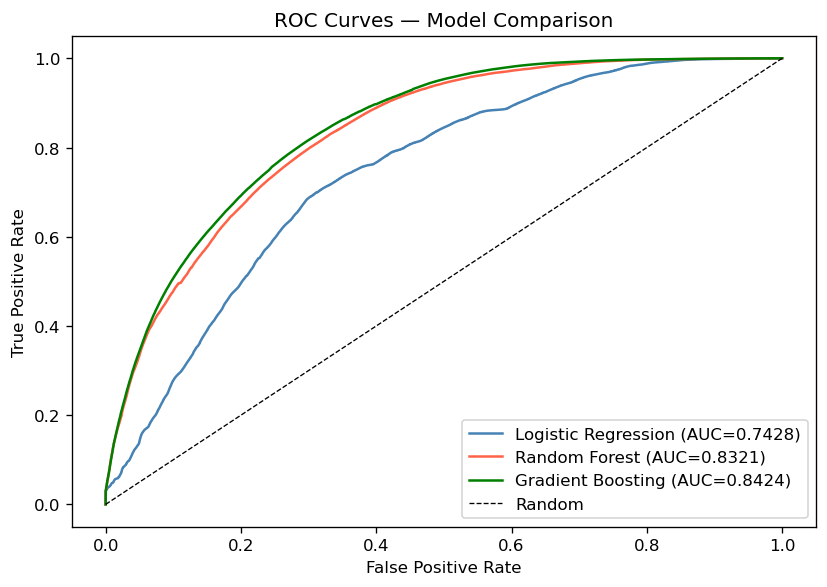

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['steelblue', 'tomato', 'green']

for i, r in enumerate(all_results):
    fpr, tpr, _ = roc_curve(y_test, r['test_prob'])
    auc = r['test']['AUC']
    ax.plot(fpr, tpr, color=colors[i % len(colors)],
            linewidth=1.5, label=f"{r['name']} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '03_roc_curves.png'))  # FIXED: fig.savefig
plt.show()

## 10. Save Best Model

In [15]:
model_path = os.path.join(BASE_DIR, 'best_model.pkl')
joblib.dump(best_model, model_path)

training_rows = X_model_train.shape[0] if best_name != 'Random Forest' else X_rf_train.shape[0]
model_meta = {
    'model_name': best_name,
    'objective': 'approval_class_f1',
    'threshold': float(best_threshold),
    'test_auc': float(final_results['test']['AUC']),
    'test_f1': float(final_results['test']['F1']),
    'test_f1_denial': float(final_results['test']['F1_denial']),
    'test_accuracy': float(final_results['test']['Accuracy']),
    'test_brier': float(final_results['test']['Brier']),
    'g_gap_auc': float(final_results['test']['AUC'] - final_results['train']['AUC']),
    'train_approval_rate': float(y_model_train.mean()),
    'test_approval_rate': float(y_test.mean()),
    'train_size': int(training_rows),
    'test_size': int(len(X_test)),
    'feature_columns': X_train.columns.tolist(),
    'n_features': int(X_train.shape[1]),
    'random_state': RANDOM_STATE,
    'model_sample_size': int(len(X_model_train)),
    'tune_sample_size': int(len(X_tune_train)),
    'rf_fit_sample_size': int(len(X_rf_train)),
}

with open(os.path.join(BASE_DIR, 'model_meta.json'), 'w') as f:
    json.dump(model_meta, f, indent=2)

selected_model_summary = pd.DataFrame([
    {
        'Model': best_name,
        'Threshold Used': round(best_threshold, 4),
        'Test AUC': round(final_results['test']['AUC'], 4),
        'Test F1': round(final_results['test']['F1'], 4),
        'Test F1 Denial': round(final_results['test']['F1_denial'], 4),
        'Test Accuracy': round(final_results['test']['Accuracy'], 4),
        'Test Brier': round(final_results['test']['Brier'], 4),
        'G_gap AUC': round(final_results['test']['AUC'] - final_results['train']['AUC'], 4),
    }
])
selected_model_summary.to_csv(os.path.join(TABLES_DIR, '03_selected_model_summary.csv'), index=False)
selected_model_summary.to_csv(os.path.join(TABLES_DIR, '03_model_comparison.csv'), index=False)

print('Saved:')
print(f'  best_model.pkl  ({os.path.getsize(model_path) / 1e6:.1f} MB)')
print('  model_meta.json')
print('  tables/03_model_comparison_default_threshold.csv')
print('  tables/03_selected_model_summary.csv')
print('  tables/03_model_comparison.csv  (presentation-ready selected model summary)')
print(json.dumps({k: v for k, v in model_meta.items() if k != 'feature_columns'}, indent=2))

Saved:
  best_model.pkl  (0.4 MB)
  model_meta.json
  tables/03_model_comparison_default_threshold.csv
  tables/03_selected_model_summary.csv
  tables/03_model_comparison.csv  (presentation-ready selected model summary)
{
  "model_name": "Gradient Boosting",
  "objective": "approval_class_f1",
  "threshold": 0.7289265594650804,
  "test_auc": 0.8424414137260792,
  "test_f1": 0.9037310429795872,
  "test_f1_denial": 0.578492203326684,
  "test_accuracy": 0.8432601862782166,
  "test_brier": 0.13504946576740276,
  "g_gap_auc": -0.0015091688632826727,
  "train_approval_rate": 0.757156,
  "test_approval_rate": 0.7571560101711254,
  "train_size": 500000,
  "test_size": 1732355,
  "n_features": 21,
  "random_state": 42,
  "model_sample_size": 500000,
  "tune_sample_size": 100000,
  "rf_fit_sample_size": 200000
}
